In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

clinical_gex = pl.read_csv(f"../dataset/created/clinical_gex/clinical_gex.csv")
clinical_gex

patientID,sex,age,AJCC_stage,M_stage,LDH,PFS_status,PFS_month,drug,BOR,BRAF_mut,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,sample_id,source,Method,CEBPZ,SLC38A5,GJA4,TUBGCP2,FMO6P,HPCA,NUP54,IDH2,TTLL6,PLEKHB2,SRD5A3,GOLGA3,BNIP1,SHC3,ZNF121,PCDHB6,PIGY,PTDSS2,ZCCHC14,CLEC12A,…,SLC35D1,GBP3,S100A13,MRPS15,S100B,CSTA,TM7SF2,TBC1D17,CDH6,CLK1,CCT3,KAT2B,NRXN3,OSBPL2,CASD1,KPNA1,RSPRY1,SLC38A4,ZNF83,PILRA,SEC61G,TM9SF4,CLEC4A,HDAC8,RP1L1,CCND2,RPGRIP1,FER,DCLK1,CENPL,FZD1,UBE2A,FBN2,KIAA1586,CLIC5,HAUS6,MIRLET7D
str,str,i64,str,str,str,f64,f64,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""YR_3053""","""male""",26,"""IV""","""M1B""","""elevated""",1.0,2.9,"""vemurafenib""","""PD""","""V600E""",null,"""no""","""no""","""03660555B""","""Yan et al.""","""RNA-seq""",6.955717,4.849514,5.184317,6.261257,4.660834,3.986734,6.635915,6.802467,4.453381,6.813892,4.661003,7.627438,5.250329,4.004573,4.109703,4.256918,8.310859,6.214321,6.113834,4.50776,…,4.278239,4.827148,9.067908,7.492706,8.616702,4.204594,5.31418,5.735105,4.343083,7.060071,8.892597,7.321783,4.216152,6.60419,5.05213,6.28592,6.647892,4.056877,5.524593,5.575115,9.565077,7.364875,5.140948,4.759397,3.895505,6.186238,3.880128,4.848412,5.765024,5.405917,5.576334,6.995104,4.997314,4.600878,3.988906,4.463209,4.004989
"""YR_3708""","""female""",58,"""IV""","""M1A""","""normal""",0.0,13.2,"""vemurafenib""","""CR""","""V600E""",null,"""no""","""no""","""03660598B""","""Yan et al.""","""RNA-seq""",6.903313,4.760713,5.182953,6.246314,4.656326,3.9834,6.340442,6.731452,4.961898,6.970269,5.070413,7.136551,5.431233,4.032248,4.562794,4.357142,8.395555,6.538542,6.315685,4.496549,…,4.16893,4.964962,9.030322,7.964037,7.824407,4.010673,5.433578,5.726959,4.33709,6.458698,8.614253,6.695091,4.128834,6.657232,4.843614,6.321173,6.654364,4.031666,5.649405,5.394635,9.410422,7.301377,5.093544,4.926181,3.958097,6.078771,3.884812,5.229689,5.921719,5.427977,5.617456,7.314188,4.965099,4.659288,3.988537,4.603643,4.324637
"""YR_3705""","""male""",45,"""IV""","""M1A""","""normal""",0.0,17.4,"""vemurafenib""","""CR""","""V600E""",null,"""no""","""no""","""03660602B""","""Yan et al.""","""RNA-seq""",7.303079,4.837887,5.224024,6.301384,4.66801,3.986592,6.616884,6.921311,4.341289,6.757447,4.60294,7.021258,5.34578,4.012699,4.750888,4.531348,7.816267,6.198656,5.942283,4.840989,…,4.233452,6.673316,9.34911,7.355079,7.443815,4.519421,5.357443,5.230466,4.336678,7.463156,8.141407,7.28486,4.921228,6.475606,5.080361,6.315992,6.886915,4.107176,6.280969,6.537383,9.300872,6.888,5.553022,4.988674,3.874813,6.272887,3.894784,5.188426,5.713174,5.427922,5.515963,7.185057,5.426698,5.028254,3.996558,4.800874,4.348986
"""YR_1106""","""male""",48,"""IIIC""",null,"""normal""",1.0,1.4,"""vemurafenib + cobimetinib""","""PD""","""V600E""",null,"""no""","""no""","""04240076F""","""Yan et al.""","""RNA-seq""",6.563531,5.142994,5.313483,6.368596,4.719741,3.989341,6.379517,7.243837,4.319912,6.780813,4.82197,7.151306,5.30894,4.011027,4.160335,4.267944,7.876148,6.221171,5.973847,4.627604,…,4.226949,5.529917,8.192637,7.203379,4.875958,4.804569,5.284931,5.191528,4.447155,6.833793,7.931538,6.210914,4.144073,6.425488,4.831051,6.130225,6.629439,4.072871,5.643834,6.771619,9.757358,7.085428,5.471083,4.790566,3.885719,6.217133,3.896916,4.883034,5.817023,5.396312,5.722212,6.983151,5.478849,4.623254,3.996295,4.441287,4.777784
"""YR_1110""","""male""",33,"""IV""","""M1C""","""normal""",1.0,1.4,"""vemurafenib + cobimetinib""","""PD""","""V600E""",null,"""no""","""no""","""04240106F""","""Yan et al.""","""RNA-seq""",6.741286,4.752592,5.21613,6.378208,4.6942,3.993966,6.801888,6.782238,4.458427,6.667538,4.747021,7.163027,5.279867,4.012122,4.453425,4.534619,9.245493,6.819853,6.112638,4.479754,…,4.335892,4.257765,8.101323,7.5861

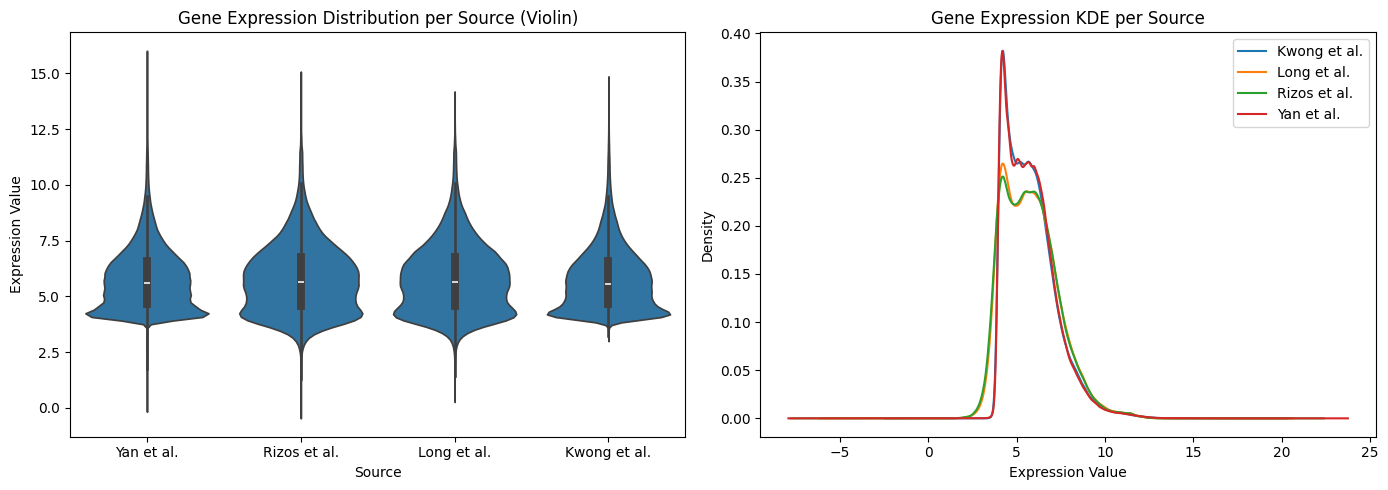

In [2]:
# Distribution of gene expression values per source
import seaborn as sns

clinical_cols = ["patientID", "sex", "age", "AJCC_stage", "M_stage", "LDH",
                 "PFS_status", "PFS_month", "drug", "BOR", "BRAF_mut",
                 "brain_metastasis", "immunotherapy_treatment", "pre_MAPKi_treatment",
                 "sample_id", "source", "Method"]
gene_cols = [c for c in clinical_gex.columns if c not in clinical_cols]

# Melt gene values with source label using polars
gene_df = clinical_gex.select(["source"] + gene_cols)
gene_values = (
    gene_df
    .unpivot(index="source", on=gene_cols, variable_name="gene", value_name="expression")
    .to_pandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot
sns.violinplot(data=gene_values, x="source", y="expression", ax=axes[0], density_norm="width")
axes[0].set_title("Gene Expression Distribution per Source (Violin)")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Expression Value")

# KDE plot per source
for src, grp in gene_values.groupby("source"):
    grp["expression"].plot.kde(ax=axes[1], label=src)
axes[1].set_title("Gene Expression KDE per Source")
axes[1].set_xlabel("Expression Value")
axes[1].legend()

plt.tight_layout()
plt.show()